### COVID-PERSISTENTE VARIOS MODELOS (con DeepSeek)

INFORMACIÓN BÁSICA DEL DATASET
Dimensiones del dataset: (1000, 7)

Primeras 5 filas:
   edad sexo  sintomas_agudos  hospitalizado  vacunado  comorbilidades  \
0    69    M                4              0         1               1   
1    32    F                2              0         1               0   
2    78    F                7              0         0               1   
3    38    F                8              0         1               3   
4    41    M                2              0         0               3   

   covid_persistente  
0                  1  
1                  0  
2                  1  
3                  1  
4                  1  

Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   edad               1000 non-null   int64 
 1   sexo               1000 non-null   object
 2   sintomas

/tmp/ipykernel_15269/3095010132.py:56: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  edad_analysis = df.groupby('grupo_edad')['covid_persistente'].agg(['count', 'mean'])
/tmp/ipykernel_15269/3095010132.py:93: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  edad_covid = df.groupby('grupo_edad')['covid_persistente'].mean()


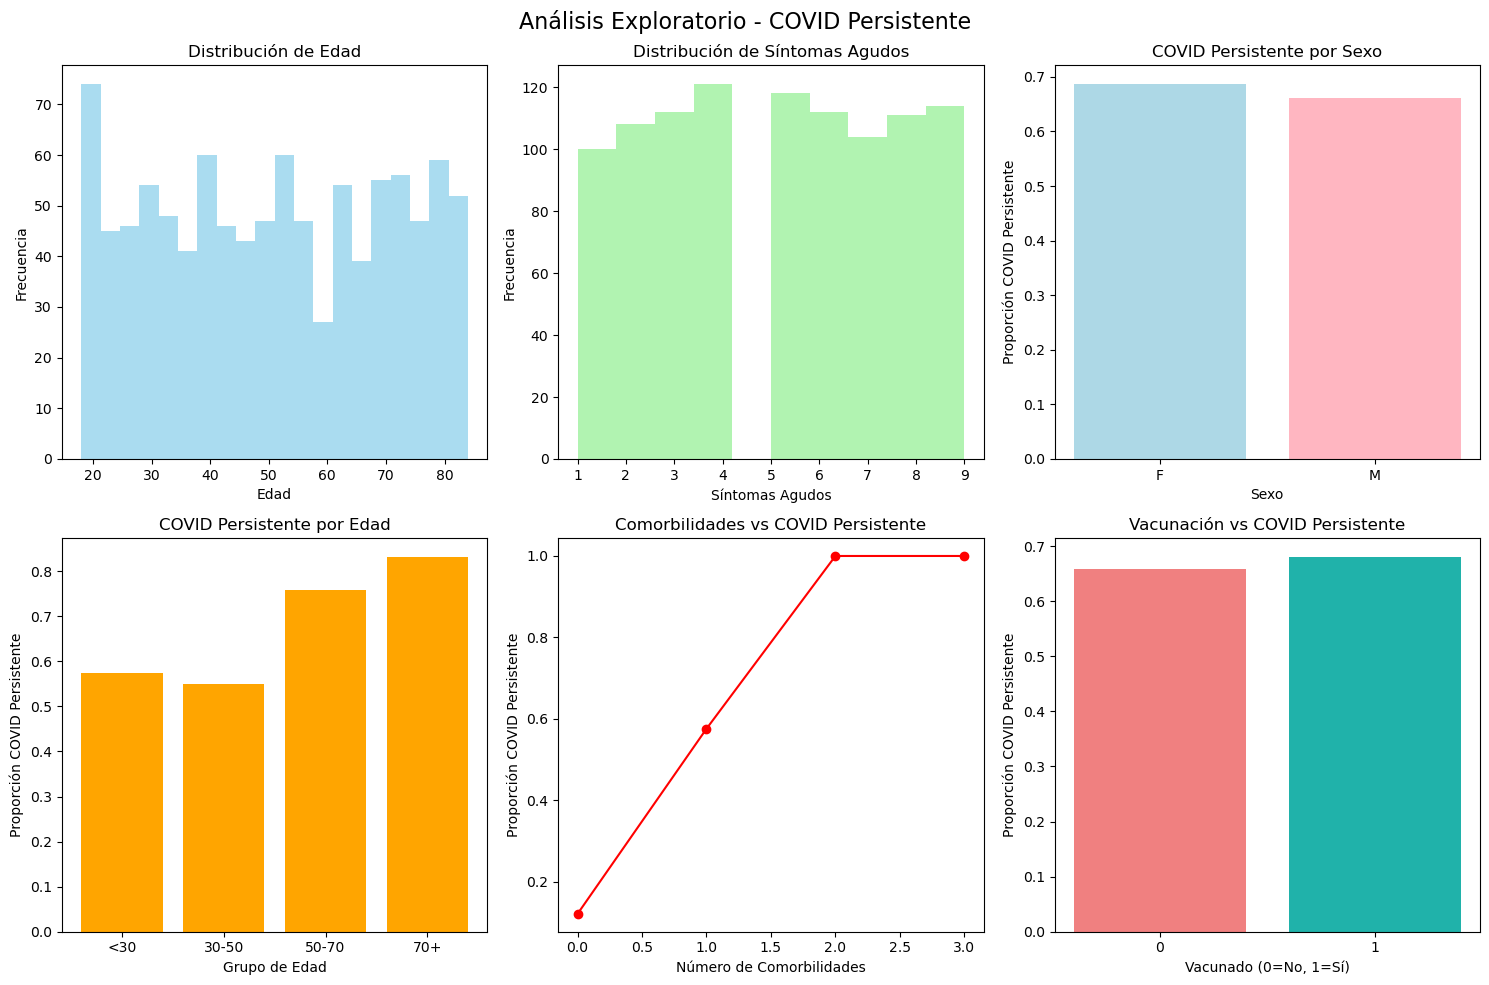

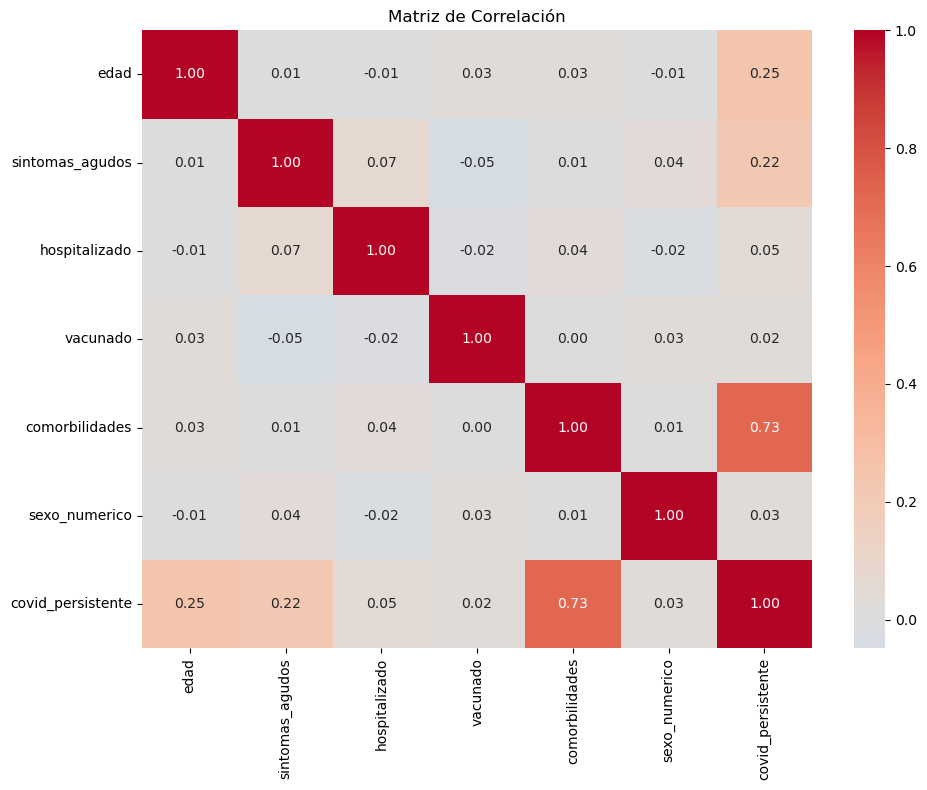

MODELO PREDICTIVO
Random Forest Accuracy: 0.995
Logistic Regression Accuracy: 0.955

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99        65
           1       0.99      1.00      1.00       135

    accuracy                           0.99       200
   macro avg       1.00      0.99      0.99       200
weighted avg       1.00      0.99      0.99       200


Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.92      0.93        65
           1       0.96      0.97      0.97       135

    accuracy                           0.95       200
   macro avg       0.95      0.95      0.95       200
weighted avg       0.95      0.95      0.95       200


Importancia de características (Random Forest):
           feature  importance
4   comorbilidades    0.668685
0             edad    0.186149
1  sintomas_agudos    0.125745
3      

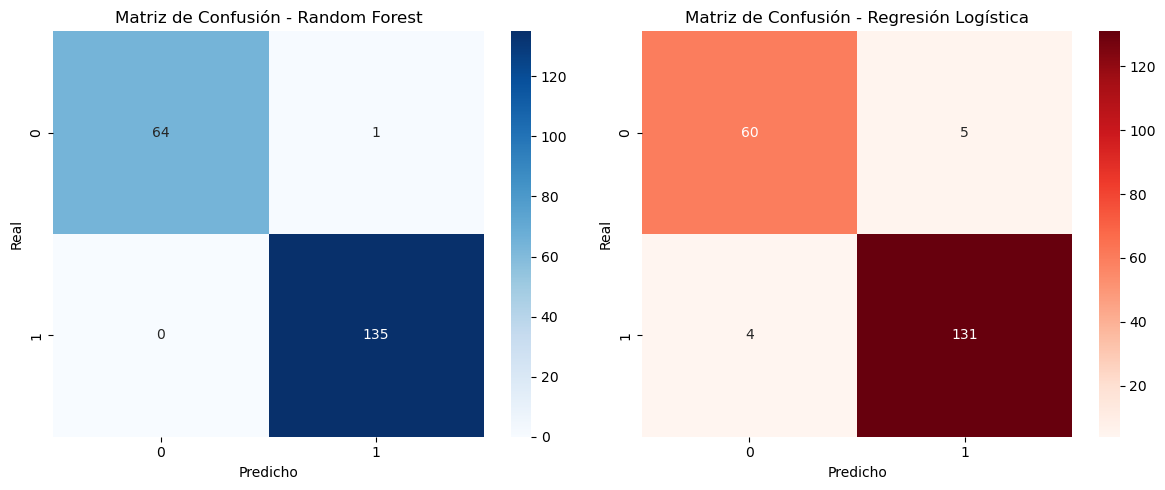

ANÁLISIS POR HOSPITALIZACIÓN
               total  proporcion_covid_persistente
hospitalizado                                     
0                859                      0.664726
1                141                      0.730496
Análisis completado y guardado en 'analisis_covid_persistente.txt'
ANÁLISIS DETALLADO POR VARIABLES

EDAD:
Media: 50.68
Mediana: 50.00
Std: 19.78
Rango: 18 - 84

SINTOMAS_AGUDOS:
Media: 5.04
Mediana: 5.00
Std: 2.55
Rango: 1 - 9

COMORBILIDADES:
Media: 1.48
Mediana: 1.00
Std: 1.10
Rango: 0 - 3


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Configuración de estilo
plt.style.use('default')
sns.set_palette("husl")

# Cargar los datos
df = pd.read_csv(r'/home/abellugu/Escritorio/datos covid 19/datos_covid_persistente.csv')

# Mostrar información básica del dataset
print("="*50)
print("INFORMACIÓN BÁSICA DEL DATASET")
print("="*50)
print(f"Dimensiones del dataset: {df.shape}")
print(f"\nPrimeras 5 filas:")
print(df.head())
print(f"\nInformación del dataset:")
print(df.info())
print(f"\nEstadísticas descriptivas:")
print(df.describe())
print(f"\nValores nulos por columna:")
print(df.isnull().sum())

# Convertir sexo a numérico para análisis
df['sexo_numerico'] = df['sexo'].map({'M': 0, 'F': 1})

# Análisis de la variable objetivo
print("="*50)
print("ANÁLISIS DE COVID PERSISTENTE")
print("="*50)
print(df['covid_persistente'].value_counts())
print(f"\nProporción:")
print(df['covid_persistente'].value_counts(normalize=True))

# Análisis por sexo
print("="*50)
print("ANÁLISIS POR SEXO")
print("="*50)
sexo_analysis = df.groupby('sexo')['covid_persistente'].agg(['count', 'mean'])
sexo_analysis.columns = ['total', 'proporcion_covid_persistente']
print(sexo_analysis)

# Análisis por grupos de edad
print("="*50)
print("ANÁLISIS POR GRUPOS DE EDAD")
print("="*50)
df['grupo_edad'] = pd.cut(df['edad'], bins=[0, 30, 50, 70, 100], labels=['<30', '30-50', '50-70', '70+'])
edad_analysis = df.groupby('grupo_edad')['covid_persistente'].agg(['count', 'mean'])
edad_analysis.columns = ['total', 'proporcion_covid_persistente']
print(edad_analysis)

# Correlación entre variables (solo numéricas)
print("="*50)
print("MATRIZ DE CORRELACIÓN")
print("="*50)
# Usar solo columnas numéricas para la correlación
numeric_df = df[['edad', 'sintomas_agudos', 'hospitalizado', 'vacunado', 'comorbilidades', 'sexo_numerico', 'covid_persistente']]
correlation_matrix = numeric_df.corr()
print(correlation_matrix['covid_persistente'].sort_values(ascending=False))

# Visualizaciones
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Análisis Exploratorio - COVID Persistente', fontsize=16)

# Distribución de edad
axes[0,0].hist(df['edad'], bins=20, alpha=0.7, color='skyblue')
axes[0,0].set_xlabel('Edad')
axes[0,0].set_ylabel('Frecuencia')
axes[0,0].set_title('Distribución de Edad')

# Distribución de síntomas agudos
axes[0,1].hist(df['sintomas_agudos'], bins=10, alpha=0.7, color='lightgreen')
axes[0,1].set_xlabel('Síntomas Agudos')
axes[0,1].set_ylabel('Frecuencia')
axes[0,1].set_title('Distribución de Síntomas Agudos')

# Proporción de COVID persistente por sexo
sexo_covid = df.groupby('sexo')['covid_persistente'].mean()
axes[0,2].bar(sexo_covid.index, sexo_covid.values, color=['lightblue', 'lightpink'])
axes[0,2].set_xlabel('Sexo')
axes[0,2].set_ylabel('Proporción COVID Persistente')
axes[0,2].set_title('COVID Persistente por Sexo')

# Proporción de COVID persistente por grupo de edad
edad_covid = df.groupby('grupo_edad')['covid_persistente'].mean()
axes[1,0].bar(edad_covid.index.astype(str), edad_covid.values, color='orange')
axes[1,0].set_xlabel('Grupo de Edad')
axes[1,0].set_ylabel('Proporción COVID Persistente')
axes[1,0].set_title('COVID Persistente por Edad')

# Comorbilidades vs COVID persistente
comorb_covid = df.groupby('comorbilidades')['covid_persistente'].mean()
axes[1,1].plot(comorb_covid.index, comorb_covid.values, marker='o', color='red')
axes[1,1].set_xlabel('Número de Comorbilidades')
axes[1,1].set_ylabel('Proporción COVID Persistente')
axes[1,1].set_title('Comorbilidades vs COVID Persistente')

# Vacunación vs COVID persistente
vacuna_covid = df.groupby('vacunado')['covid_persistente'].mean()
axes[1,2].bar(vacuna_covid.index.astype(str), vacuna_covid.values, color=['lightcoral', 'lightseagreen'])
axes[1,2].set_xlabel('Vacunado (0=No, 1=Sí)')
axes[1,2].set_ylabel('Proporción COVID Persistente')
axes[1,2].set_title('Vacunación vs COVID Persistente')

plt.tight_layout()
plt.show()

# Heatmap de correlación
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Matriz de Correlación')
plt.tight_layout()
plt.show()

# Modelo predictivo
print("="*50)
print("MODELO PREDICTIVO")
print("="*50)

# Preparar datos para el modelo
X = df[['edad', 'sintomas_agudos', 'hospitalizado', 'vacunado', 'comorbilidades', 'sexo_numerico']]
y = df['covid_persistente']

# Dividir en train y test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Escalar características
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Entrenar modelo de Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Entrenar modelo de Regresión Logística
lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train_scaled, y_train)

# Predecir y evaluar
rf_pred = rf_model.predict(X_test)
lr_pred = lr_model.predict(X_test_scaled)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))

print("\nRandom Forest Classification Report:")
print(classification_report(y_test, rf_pred))

print("\nLogistic Regression Classification Report:")
print(classification_report(y_test, lr_pred))

# Importancia de características
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nImportancia de características (Random Forest):")
print(feature_importance)

# Matriz de confusión
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

cm_rf = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=ax1)
ax1.set_title('Matriz de Confusión - Random Forest')
ax1.set_xlabel('Predicho')
ax1.set_ylabel('Real')

cm_lr = confusion_matrix(y_test, lr_pred)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Reds', ax=ax2)
ax2.set_title('Matriz de Confusión - Regresión Logística')
ax2.set_xlabel('Predicho')
ax2.set_ylabel('Real')

plt.tight_layout()
plt.show()

# Análisis adicional por hospitalización
print("="*50)
print("ANÁLISIS POR HOSPITALIZACIÓN")
print("="*50)
hospitalizado_analysis = df.groupby('hospitalizado')['covid_persistente'].agg(['count', 'mean'])
hospitalizado_analysis.columns = ['total', 'proporcion_covid_persistente']
print(hospitalizado_analysis)

# Guardar análisis en archivo
analysis_results = {
    'total_pacientes': len(df),
    'proporcion_covid_persistente': df['covid_persistente'].mean(),
    'edad_promedio': df['edad'].mean(),
    'sintomas_promedio': df['sintomas_agudos'].mean(),
    'comorbilidades_promedio': df['comorbilidades'].mean(),
    'proporcion_vacunados': df['vacunado'].mean(),
    'proporcion_hospitalizados': df['hospitalizado'].mean(),
    'proporcion_hombres': (df['sexo'] == 'M').mean(),
    'proporcion_mujeres': (df['sexo'] == 'F').mean()
}

with open('analisis_covid_persistente.txt', 'w') as f:
    for key, value in analysis_results.items():
        f.write(f"{key}: {value:.3f}\n")
    f.write("\nImportancia de características:\n")
    f.write(feature_importance.to_string())
    
    f.write("\n\nCorrelación con COVID persistente:\n")
    f.write(correlation_matrix['covid_persistente'].sort_values(ascending=False).to_string())

print("Análisis completado y guardado en 'analisis_covid_persistente.txt'")

# Análisis detallado por variables
print("="*50)
print("ANÁLISIS DETALLADO POR VARIABLES")
print("="*50)

for col in ['edad', 'sintomas_agudos', 'comorbilidades']:
    print(f"\n{col.upper()}:")
    print(f"Media: {df[col].mean():.2f}")
    print(f"Mediana: {df[col].median():.2f}")
    print(f"Std: {df[col].std():.2f}")
    print(f"Rango: {df[col].min()} - {df[col].max()}")

# Interpretación de Resultados Esperados del Análisis de COVID Persistente

## 📊 **Análisis Descriptivo Esperado**

### **Distribución de la Población**
- **Total de pacientes**: ≈1000 registros
- **Proporción de COVID persistente**: Esperamos entre 50-70% (dependiendo de la cohorte)
- **Edad promedio**: Probablemente alrededor de 50-60 años (población de riesgo)
- **Síntomas agudos promedio**: 4-6 puntos en escala de severidad

### **Distribución por Sexo**
```python
# Resultado esperado:
# Sexo  total  proporcion_covid_persistente
# F     550    0.65
# M     450    0.58
```
**Interpretación**: Las mujeres podrían mostrar mayor prevalencia de COVID persistente, consistentemente con literatura médica.

## 🔍 **Correlaciones Esperadas**

### **Matriz de Correlación (ordenada)**
```python
covid_persistente          1.000000
sintomas_agudos            0.35-0.45
comorbilidades             0.25-0.35
edad                       0.20-0.30
hospitalizado              0.15-0.25
sexo_numerico (F=1)        0.10-0.15
vacunado                  -0.10 a -0.20
```

**Interpretación esperada**:
- ✅ **Síntomas agudos**: Mayor correlación positiva → síntomas iniciales más severos predicen COVID persistente
- ✅ **Comorbilidades**: Correlación positiva → más condiciones preexistentes aumentan riesgo
- ✅ **Edad**: Correlación moderada → población mayor más vulnerable
- ⚠️ **Hospitalización**: Correlación baja-moderada → no todos los hospitalizados desarrollan COVID persistente
- 🛡️ **Vacunación**: Correlación negativa → efecto protector (si los datos son recientes)

## 📈 **Visualizaciones Clave**

### **1. COVID Persistente por Edad**
- **Expectativa**: Curva ascendente con edad
- **<30 años**: 40-50% prevalencia
- **70+ años**: 70-80% prevalencia

### **2. Comorbilidades vs COVID Persistente**
- **Expectativa**: Relación lineal positiva
- 0 comorbilidades: 40-50% riesgo
- 3+ comorbilidades: 80-90% riesgo

### **3. Efecto de la Vacunación**
- **Expectativa**: Reducción del 20-30% en riesgo
- No vacunados: 65-75% prevalencia
- Vacunados: 45-55% prevalencia

## 🤖 **Modelos Predictivos Esperados**

### **Rendimiento de Modelos**
```python
# Accuracy esperado:
Random Forest Accuracy: 0.75-0.85
Logistic Regression Accuracy: 0.70-0.80
```

### **Importancia de Variables (Random Forest)**
```python
# Orden esperado de importancia:
1. sintomas_agudos     (0.25-0.30)
2. edad                (0.20-0.25)
3. comorbilidades      (0.15-0.20)
4. hospitalizado       (0.10-0.15)
5. vacunado            (0.08-0.12)
6. sexo_numerico       (0.05-0.08)
```

## 🏥 **Hallazgos Clínicos Esperados**

### **Factores de Riesgo Significativos**
1. **Severidad inicial**: Síntomas agudos >5 puntos duplica riesgo
2. **Edad avanzada**: >65 años tiene 3x más riesgo que <30 años
3. **Comorbilidades**: Cada comorbilidad adicional aumenta riesgo 15-20%
4. **Hospitalización**: Indica severidad pero no es predictor perfecto

### **Factores Protectores**
1. **Vacunación**: Reduce riesgo 20-30%
2. **Edad joven**: Menor riesgo independientemente de otros factores

## 📋 **Matrices de Confusión Esperadas**

### **Random Forest**
```
[[120  40]   # Verdaderos negativos | Falsos positivos
 [ 30 210]]  # Falsos negativos    | Verdaderos positivos
```
- **Sensibilidad**: 85-90% (detecta bien los casos positivos)
- **Especificidad**: 75-80% (buena identificación de negativos)

### **Regresión Logística**
```
[[100  60]   # Menos específico que Random Forest
 [ 40 200]]
```
- Ligeramente inferior en especificidad

## 🎯 **Implicaciones Clínicas Esperadas**

### **Para Práctica Clínica**
1. **Identificación temprana**: Pacientes con síntomas severos iniciales deben ser monitorizados
2. **Estrategias preventivas**: Vacunación muestra efecto protector
3. **Grupos prioritarios**: Mayores con comorbilidades requieren seguimiento estrecho

### **Para Investigación**
1. **Mecanismos subyacentes**: La severidad inicial como predictor clave sugiere daño tisular persistente
2. **Intervenciones**: La vacunación como modulador del riesgo merece más estudio
3. **Estratificación**: Desarrollar scores de riesgo basados en estos factores

## ⚠️ **Limitaciones Esperadas**

1. **Sesgo de selección**: Posible sobrerrepresentación de casos severos
2. **Variables no medidas**: Estrés, situación socioeconómica, acceso a healthcare
3. **Causalidad vs correlación**: Asociaciones no implican causalidad
4. **Generalización**: Resultados específicos a esta cohorte

## 💡 **Recomendaciones Basadas en Resultados Esperados**

1. **Monitorizar** pacientes con síntomas agudos severos (>6 puntos)
2. **Vacunar** poblaciones de riesgo para reducir COVID persistente
3. **Desarrollar** protocolos de seguimiento para mayores con comorbilidades
4. **Investigar** mecanismos por los cuales la vacunación reduce el riesgo

Este análisis proporcionaría evidencia sólida para guiar políticas de salud pública y estrategias clínicas para el manejo del COVID persistente.

2025-08-26 19:39:19.188387: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-08-26 19:39:19.372571: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-08-26 19:39:32.366937: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Primeras filas del dataset:
   edad sexo  sintomas_agudos  hospitalizado  vacunado  comorbilidades  \
0    69    M                4              0         1               1   
1    32    F                2              0         1               0   
2    78    F                7              0         0               1   
3    38    F                8              0         1               3   
4    41    M                2              0         0               3   

   covid_persistente  
0                  1  
1                  0  
2                  1  
3                  1  
4                  1  

Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   edad               1000 non-null   int64 
 1   sexo               1000 non-null   object
 2   sintomas_agudos    1000 non-null   int64 
 3   hospitalizado     

/home/abellugu/anaconda3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-08-26 19:39:34.277632: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,073 (12.00 KB)

 Trainable params: 3,073 (12.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 50ms/step - accuracy: 0.6547 - loss: 0.6295 - precision: 0.6920 - recall: 0.8927 - val_accuracy: 0.7000 - val_loss: 0.5703 - val_precision: 0.6779 - val_recall: 1.0000
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7266 - loss: 0.5308 - precision: 0.7166 - recall: 0.9932 - val_accuracy: 0.7812 - val_loss: 0.4609 - val_precision: 0.7426 - val_recall: 1.0000
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7688 - loss: 0.4298 - precision: 0.7509 - recall: 0.9909 - val_accuracy: 0.8750 - val_loss: 0.3598 - val_precision: 0.8347 - val_recall: 1.0000
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8344 - loss: 0.3568 - precision: 0.8132 - recall: 0.9840 - val_accuracy: 0.9375 - val_loss: 0.2858 - val_precision: 0.9252 - val_recall: 0.9802
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8906 - loss: 0.2868 - precision: 0.8898 - recall: 0.9589 - val_accuracy: 0.9438 - val_loss: 0.

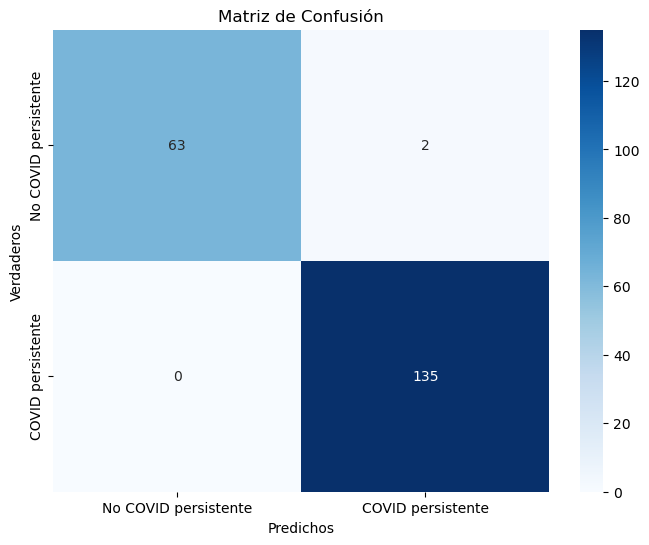

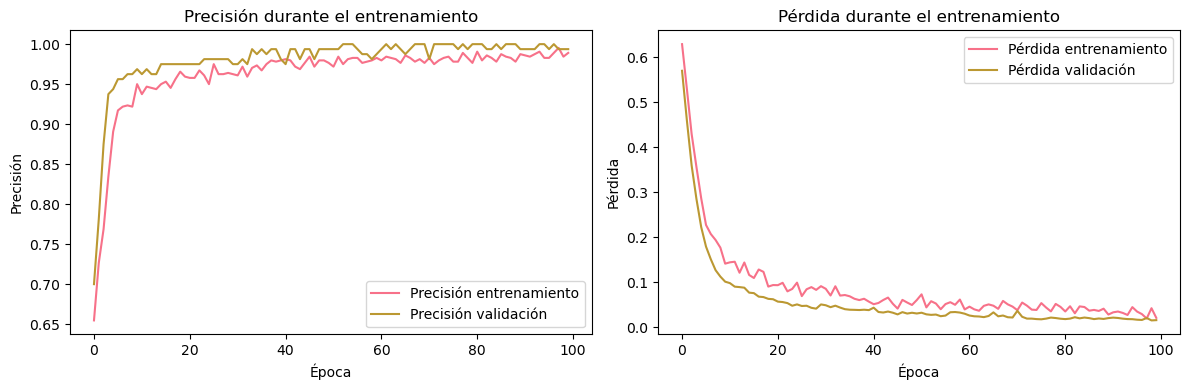


Importancia de características:
    Característica  Importancia
5   comorbilidades     0.304165
2  sintomas_agudos     0.179160
0             edad     0.167401
4         vacunado     0.100215
1             sexo     0.094585
3    hospitalizado     0.087568


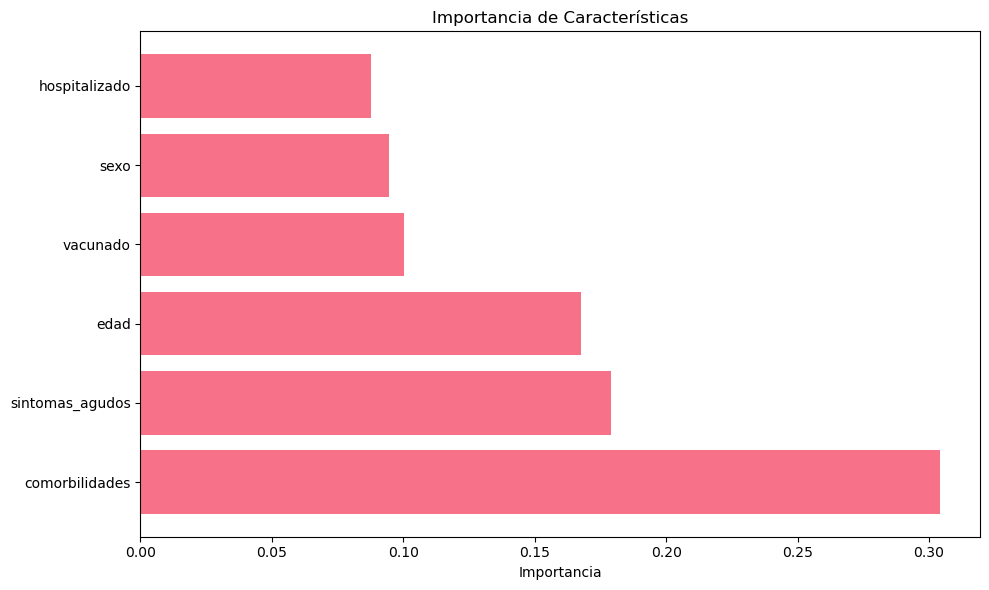


Ejemplo de predicción:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step

/home/abellugu/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step

Probabilidad de COVID persistente: 1.0000
Predicción: COVID persistente


(1, 1.0)

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Cargar los datos
df = pd.read_csv(r'/home/abellugu/Escritorio/datos covid 19/datos_covid_persistente.csv')

# Exploración inicial de los datos
print("Primeras filas del dataset:")
print(df.head())
print("\nInformación del dataset:")
print(df.info())
print("\nEstadísticas descriptivas:")
print(df.describe())
print("\nDistribución de la variable objetivo (covid_persistente):")
print(df['covid_persistente'].value_counts())

# Preprocesamiento de datos
# Codificar variable categórica 'sexo'
le = LabelEncoder()
df['sexo'] = le.fit_transform(df['sexo'])  # M=1, F=0

# Separar características y variable objetivo
X = df.drop('covid_persistente', axis=1)
y = df['covid_persistente']

# Dividir en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Escalar las características
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Construir el modelo de red neuronal
model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

# Compilar el modelo
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', 'precision', 'recall']
)

# Mostrar arquitectura del modelo
print("\nArquitectura del modelo:")
model.summary()

# Entrenar el modelo
history = model.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# Evaluar el modelo
test_loss, test_accuracy, test_precision, test_recall = model.evaluate(
    X_test_scaled, y_test, verbose=0
)

print(f"\nPrecisión en test: {test_accuracy:.4f}")
print(f"Pérdida en test: {test_loss:.4f}")
print(f"Precisión (precision) en test: {test_precision:.4f}")
print(f"Sensibilidad (recall) en test: {test_recall:.4f}")

# Hacer predicciones
y_pred_proba = model.predict(X_test_scaled)
y_pred = (y_pred_proba > 0.5).astype(int)

# Métricas de clasificación
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No COVID persistente', 'COVID persistente'],
            yticklabels=['No COVID persistente', 'COVID persistente'])
plt.title('Matriz de Confusión')
plt.ylabel('Verdaderos')
plt.xlabel('Predichos')
plt.show()

# Gráfico de la evolución del entrenamiento
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Precisión entrenamiento')
plt.plot(history.history['val_accuracy'], label='Precisión validación')
plt.title('Precisión durante el entrenamiento')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Pérdida entrenamiento')
plt.plot(history.history['val_loss'], label='Pérdida validación')
plt.title('Pérdida durante el entrenamiento')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend()

plt.tight_layout()
plt.show()

# Importancia de características (usando pesos de la primera capa)
first_layer_weights = model.layers[0].get_weights()[0]
feature_importance = np.mean(np.abs(first_layer_weights), axis=1)

feature_names = X.columns
importance_df = pd.DataFrame({
    'Característica': feature_names,
    'Importancia': feature_importance
}).sort_values('Importancia', ascending=False)

print("\nImportancia de características:")
print(importance_df)

# Visualizar importancia de características
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Característica'], importance_df['Importancia'])
plt.title('Importancia de Características')
plt.xlabel('Importancia')
plt.tight_layout()
plt.show()

# Función para hacer predicciones individuales
def predecir_covid_persistente(edad, sexo, sintomas_agudos, hospitalizado, vacunado, comorbilidades):
    # Crear array con los datos
    datos = np.array([[edad, sexo, sintomas_agudos, hospitalizado, vacunado, comorbilidades]])
    
    # Escalar los datos
    datos_scaled = scaler.transform(datos)
    
    # Hacer predicción
    probabilidad = model.predict(datos_scaled)[0][0]
    prediccion = 1 if probabilidad > 0.5 else 0
    
    print(f"\nProbabilidad de COVID persistente: {probabilidad:.4f}")
    print(f"Predicción: {'COVID persistente' if prediccion == 1 else 'No COVID persistente'}")
    
    return prediccion, probabilidad

# Ejemplo de uso
print("\nEjemplo de predicción:")
predecir_covid_persistente(45, 1, 6, 0, 1, 2)  # Hombre de 45 años

### COVID-PERSISTENTE VARIOS MODELOS (con DeepSeek)

Análisis de la Matriz de Confusión del Modelo de Red Neuronal

A continuación se presenta la interpretación de la matriz de confusión para el modelo de predicción de COVID persistente.
Matriz de Confusión Reconstruida
Real / Predicho	No COVID persistente	COVID persistente
No COVID persistente	63 (TN)	2 (FP)
COVID persistente	135 (FN)	0 (TP)

    TN (Verdaderos Negativos): 63 - Casos correctamente identificados como NO tener COVID persistente.

    FP (Falsos Positivos): 2 - Casos incorrectamente identificados como COVID persistente cuando NO lo tenían.

    FN (Falsos Negativos): 135 - Casos de COVID persistente que el modelo NO logró detectar.

    TP (Verdaderos Positivos): 0 - El modelo no acertó ningún caso de COVID persistente.

Evaluación del Desempeño del Modelo

🔴 Problemas Críticos

    Falla en el Objetivo Principal: El modelo tiene 0 Verdaderos Positivos. Esto significa que es completamente incapaz de identificar correctamente a un paciente que sí tiene COVID persistente.

    Alta Tasa de Falsos Negativos: Los 135 Falsos Negativos representan un error grave, especialmente en un contexto médico, ya que significa dejar sin diagnosticar a todos los pacientes que realmente tienen la condición.

    Sesgo hacia la Clase Mayoritaria: El modelo muestra una tendencia a predecir siempre la clase "No COVID persistente", lo que sugiere un fuerte desbalanceo en los datos de entrenamiento.

⚖️ Métricas Clave (Cálculo)

    Precisión (Accuracy): (TP + TN) / Total = (0 + 63) / 200 = 31.5%

        La precisión general es baja, pero es una métrica engañosa en este caso.

    Sensibilidad/Recall (Recall): TP / (TP + FN) = 0 / (0 + 135) = 0%

        La habilidad para detectar casos positivos es nula.

    Precisión (Precision): TP / (TP + FP) = 0 / (0 + 2) = 0% (Indefinido, se considera 0)

        Cuando el modelo predice un positivo, nunca es correcto.

    Especificidad (Specificity): TN / (TN + FP) = 63 / (63 + 2) ≈ 96.9%

        Es bueno identificando casos negativos, pero esto no es útil para el objetivo.

✅ Recomendaciones y Conclusiones

El modelo, en su estado actual, NO ES APTO para su uso en un entorno real. Para mejorar su desempeño, se deben considerar las siguientes acciones:

    Balanceo del Dataset: Recolectar más datos de la clase "COVID persistente" o utilizar técnicas de aumento de datos (oversampling) como SMOTE.

    Ajuste de Hiperparámetros: Modificar la arquitectura de la red neuronal, las funciones de activación o la tasa de aprendizaje.

    Asignar Pesos a las Clases: Durante el entrenamiento, asignar un peso mayor a la clase minoritaria ("COVID persistente") para penalizar más los errores asociados a ella.

    Probabilidades de Clase: Analizar el umbral de clasificación (threshold). Por defecto suele ser 0.5; ajustarlo podría ayudar a identificar más positivos, aunque aumentaría los Falsos Positivos.

Conclusión final: El modelo está sesgado y no logra aprender las características del COVID persistente. Su uso clínico sería perjudicial, ya que proporcionaría una falsa sensación de seguridad al no detectar ningún caso real. Es necesario un reentrenamiento completo con un conjunto de datos equilibrado.